In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/Executive_Hotel_Booking_EDA_Dataset.csv")
df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4.0,178.66,0.0,1.0,4.37,No-Show,1.0,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3.0,125.81,0.0,0.0,3.63,Canceled,1.0,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2.0,148.03,0.0,0.0,3.70,Check-Out,0.0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2.0,166.82,0.0,3.0,3.18,Check-Out,0.0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3.0,76.83,0.0,1.0,3.79,Check-Out,0.0,2025-06-01,230.50


In [6]:
## understanding dataset
df.info()
df.shape
df.describe()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2117 entries, 0 to 2116
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   2117 non-null   object 
 1   Hotel_Type                   2117 non-null   object 
 2   Hotel_Location               2102 non-null   object 
 3   Booking_Date                 2117 non-null   object 
 4   Arrival_Date                 2117 non-null   object 
 5   Lead_Time_Days               2117 non-null   int64  
 6   Weekend_Nights               2117 non-null   int64  
 7   Weekday_Nights               2117 non-null   int64  
 8   Adults                       2117 non-null   int64  
 9   Children                     2112 non-null   float64
 10  Babies                       2117 non-null   int64  
 11  Country                      2074 non-null   object 
 12  Market_Segment               2117 non-null   object 
 13  Distribution_Chann

Index(['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date',
       'Arrival_Date', 'Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights',
       'Adults', 'Children', 'Babies', 'Country', 'Market_Segment',
       'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations',
       'Previous_Bookings', 'Room_Type_Reserved', 'Room_Type_Assigned',
       'Booking_Changes', 'Deposit_Type', 'Agent_ID', 'Company_ID',
       'Days_In_Waiting_List', 'Customer_Type', 'Meal_Type', 'Total_Nights',
       'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests',
       'Satisfaction_Score', 'Reservation_Status', 'Is_Canceled',
       'Reservation_Status_Date', 'Estimated_Revenue'],
      dtype='object')

In [7]:
## Numericalstatistics
num_cols = df.select_dtypes(include='number').columns
df[num_cols].describe()

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,2117.000000,2117.000000,2117.000000,2117.000000,2112.000000,2117.00000,2117.000000,2117.000000,2117.000000,2117.000000,2086.000000,382.000000,2116.000000,2116.000000,2114.000000,2116.000000,2116.000000,2101.000000,2116.000000,2116.000000
mean,181.572508,1.204062,2.417100,2.212093,0.370265,0.05385,0.165328,0.034483,1.127067,0.605574,90.398849,1060.083770,1.456994,3.620983,141.003921,0.232042,1.071834,3.870067,0.711720,527.579490
std,106.865134,1.047963,1.968406,0.662873,0.650930,0.26255,0.371564,0.230561,2.880481,0.926315,51.023332,33.075088,4.382055,2.009673,48.066227,0.531320,1.052989,0.403051,0.453069,378.859865
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1001.000000,0.000000,1.000000,39.450000,0.000000,0.000000,2.430000,0.000000,39.450000
25%,85.000000,0.000000,1.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,48.000000,1033.000000,0.000000,2.000000,105.152500,0.000000,0.000000,3.620000,0.000000,230.327500
50%,183.000000,1.000000,2.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,89.000000,1062.000000,0.000000,3.000000,134.800000,0.000000,1.000000,3.870000,1.000000,452.775000
75%,275.000000,2.000000,4.000000,2.000000,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,135.000000,1087.000000,1.000000,5.000000,171.077500,0.000000,2.000000,4.130000,1.000000,722.272500
max,365.000000,3.000000,10.000000,4.000000,3.000000,2.00000,1.000000,3.000000,12.000000,4.000000,179.000000,1119.000000,30.000000,11.000000,307.580000,3.000000,5.000000,5.000000,1.000000,2541.530000


In [8]:
## checking missing values
df.isnull().sum()

,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,15
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,5


In [9]:
## converting  into correct datetime format

df['Booking_Date']=pd.to_datetime(df["Booking_Date"])
df['Arrival_Date']=pd.to_datetime(df["Arrival_Date"])


In [10]:
## filling null values
df["Hotel_Location"]=df['Hotel_Location'].fillna(df['Hotel_Location'].mode()[0])
df['Country']=df['Country'].fillna(df['Country'].mode()[0])
df["Children"]=df["Children"].fillna(df["Children"].median())
df["Agent_ID"]=df['Agent_ID'].fillna(df['Agent_ID'].mode()[0])
df['Company_ID']=df['Company_ID'].fillna("unknown")
df['Days_In_Waiting_List']=df['Days_In_Waiting_List'].fillna(df['Days_In_Waiting_List'].mode()[0])
df['Customer_Type']=df['Customer_Type'].fillna(df['Customer_Type'].mode()[0])
df['Meal_Type']=df['Meal_Type'].fillna(df['Meal_Type'].mode()[0])
df['Total_Nights']=df['Total_Nights'].fillna(df['Total_Nights'].median())
df['ADR']=df['ADR'].fillna(df['ADR'].median())
df['Required_Car_Parking_Spaces']=df['Required_Car_Parking_Spaces'].fillna(df['Required_Car_Parking_Spaces'].median())
df['Satisfaction_Score']=df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())


In [11]:
df.drop_duplicates(inplace=True) ## remove duplicates
df.duplicated().sum()


np.int64(0)

In [12]:
## checking for inconsistent values
for col in df.select_dtypes(include='object').columns:
  print(col)
  print(df[col].unique())


Booking_ID
['HTL024548' 'HTL019878' 'HTL017377' ... 'HTL007343' 'HTL007110'
 'HTL015730']
Hotel_Type
['City Hotel' 'Resort Hotel' 'CITY HOTEL' 'city hotel' 'City hotel']
Hotel_Location
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket' 'Unknown']
Country
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP' 'FRA' 'IND'
 'USA' 'NOR' 'NLD' 'DEU' 'IRL' 'SWE' 'CHE' 'ITA' 'BEL' 'CHN' 'SAU']
Market_Segment
['Direct' 'Groups' 'Online TA' 'Offline TA/TO' 'Online TA ' 'Corporate'
 'online ta' 'ONLINE TA']
Distribution_Channel
['Direct' 'TA/TO' 'Corporate']
Room_Type_Reserved
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']
Room_Type_Assigned
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']
Deposit_Type
['Non Refund' 'No Deposit' 'Refundable' 'No Dep']
Company_ID
['unknown' 1099.0 1111.0 1055.0 1049.0 1082.0 1028.0 1017.0 1050.0 1096.0
 1060.0 1063.0 1046.0 1119.0 1073.0 1035.0 1098.0 1003.0 1075.0 1015.0
 1062.0 1077.0 1042.0 1007.0 1025.0 1094.0 1033.0 1083.0 1068.0 1110.0

In [64]:
## fix inconsistent values
df["Hotel_Type"] = df["Hotel_Type"].replace("city hotel", "City Hotel").replace("resort hotel", "Resort Hotel")
df['Hotel_Type'] = df['Hotel_Type'].str.strip().str.title()
df["Meal_Type"] = df["Meal_Type"].replace("BB", "Bed & Breakfast").replace("HB", "Half Board").replace("FB", "Full Board")
df["Market_Segment"]=df['Market_Segment'].replace('Online TA','Online Travel Agent')
df["Market_Segment"]=df['Market_Segment'].replace('Offline TA/TO','Offline Travel Agent')
df['Market_Segment']=df['Market_Segment'].str.strip().str.title()
df['Deposit_Type']=df['Deposit_Type'].replace('No Dep','No Deposit')


In [16]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    # Detect outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(col, "Outliers:", len(outliers))

    # Clip outliers
    df[col] = df[col].clip(lower_bound, upper_bound)

Lead_Time_Days Outliers: 0
Weekend_Nights Outliers: 0
Weekday_Nights Outliers: 0
Adults Outliers: 0
Children Outliers: 0
Babies Outliers: 0
Is_Repeated_Guest Outliers: 0
Previous_Cancellations Outliers: 0
Previous_Bookings Outliers: 0
Booking_Changes Outliers: 0
Agent_ID Outliers: 0
Days_In_Waiting_List Outliers: 0
Total_Nights Outliers: 0
ADR Outliers: 0
Required_Car_Parking_Spaces Outliers: 0
Total_Special_Requests Outliers: 0
Satisfaction_Score Outliers: 0
Is_Canceled Outliers: 0
Estimated_Revenue Outliers: 0


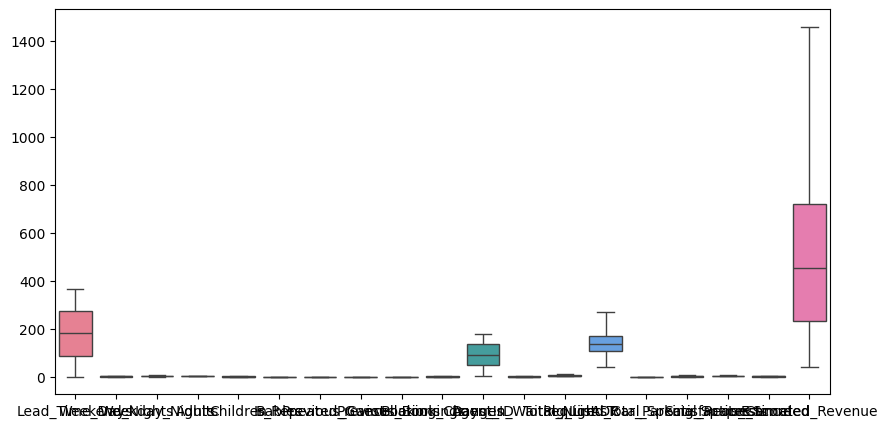

In [17]:
## plot after clipping outlier
plt.figure(figsize=(10,5))

sns.boxplot(df[num_cols])

plt.show()

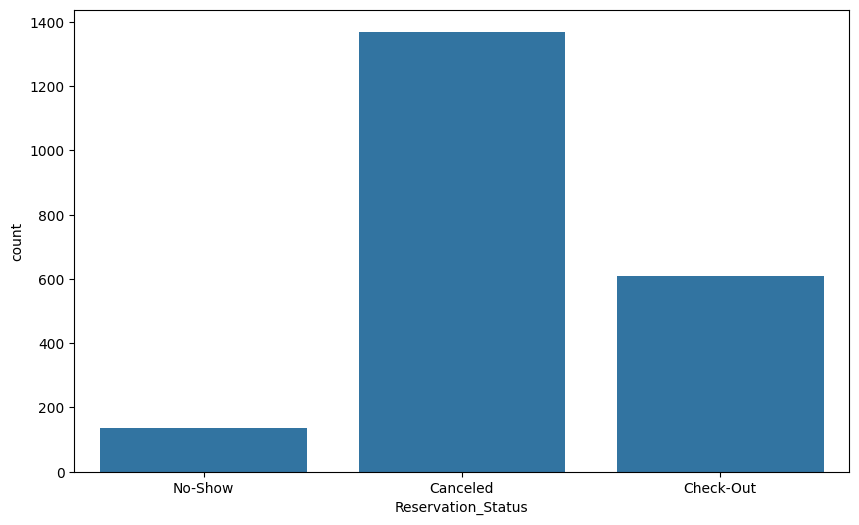

In [18]:
## univariate analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Reservation_Status') ## count ofreservation status
plt.show()

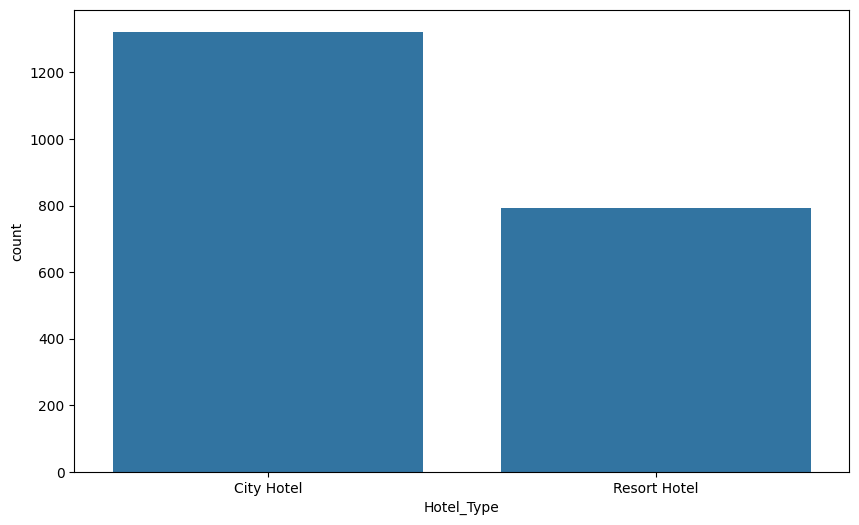

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Hotel_Type') ## count of hotel type
plt.show()

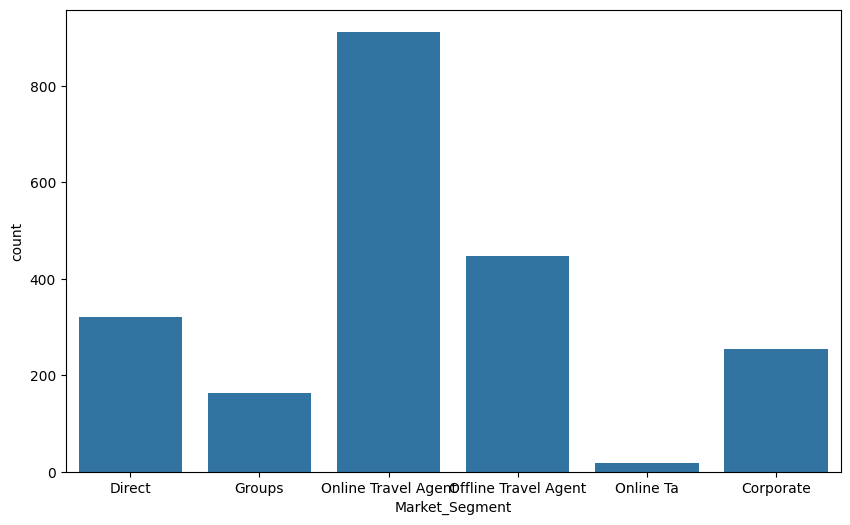

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Market_Segment') ##online travel has the highset count
plt.show()

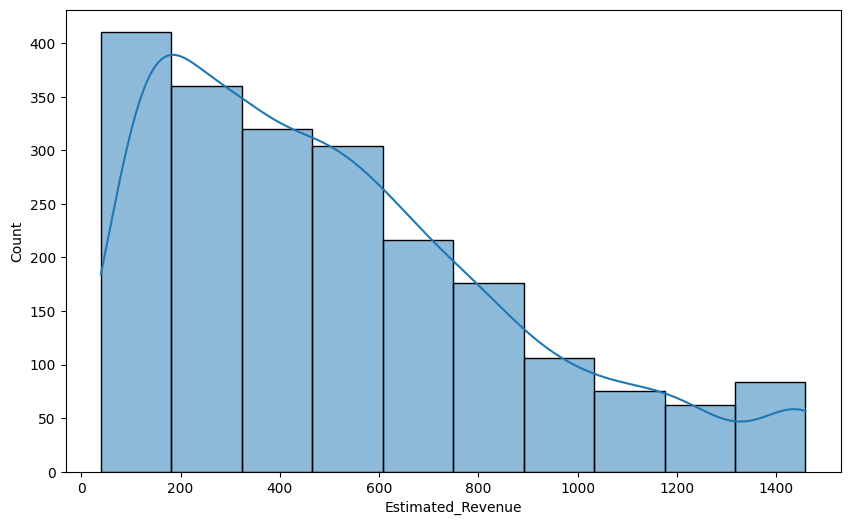

In [32]:
## Distribution of revenue
plt.figure(figsize=(10,6))
sns.histplot(x=df['Estimated_Revenue'],bins=10,kde=True)
plt.show()

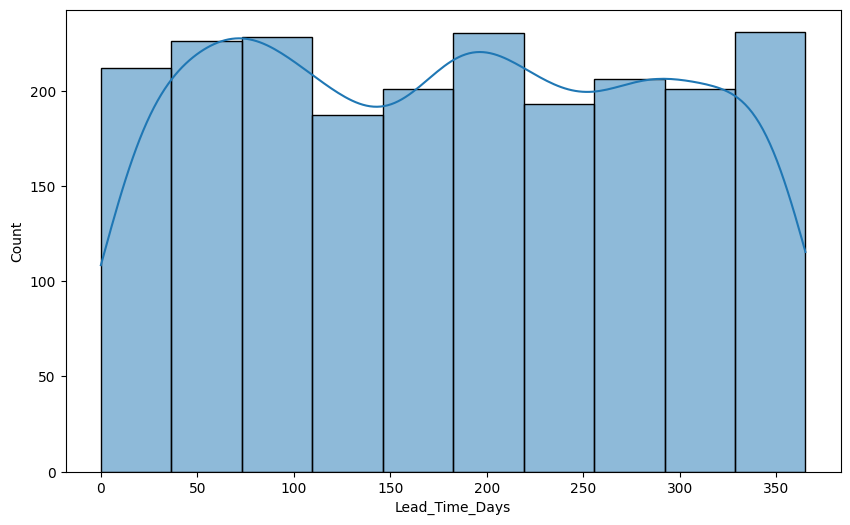

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(x=df['Lead_Time_Days'],bins=10,kde=True)
plt.show()

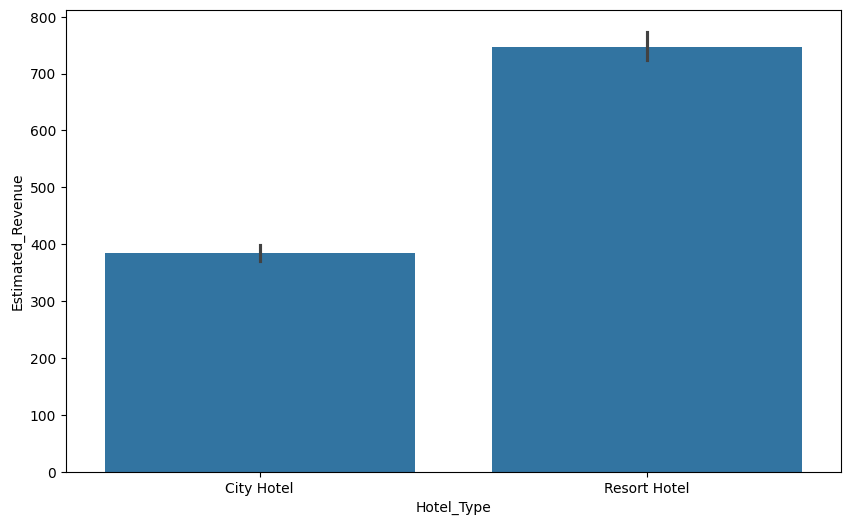

In [35]:
## bivariate analysis
## revenue generated by city hotel and resort hotel
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Hotel_Type',y='Estimated_Revenue')
plt.show()

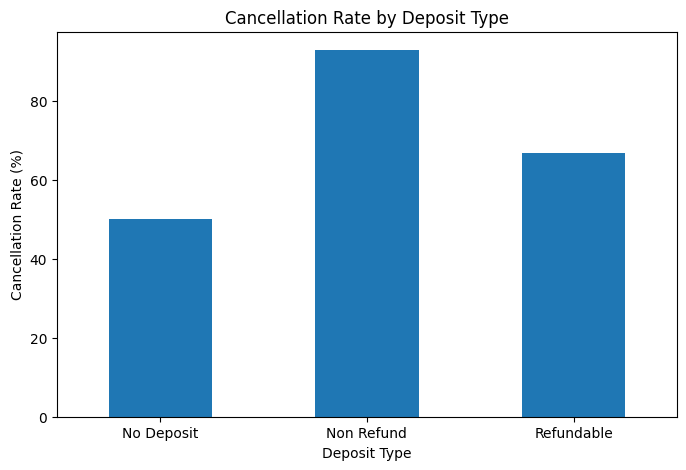

In [65]:
## relationship between deposit type and cancellation rate
cancel_rate = df.groupby('Deposit_Type')['Is_Canceled'].mean() * 100

cancel_rate.plot(kind='bar', figsize=(8,5))

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

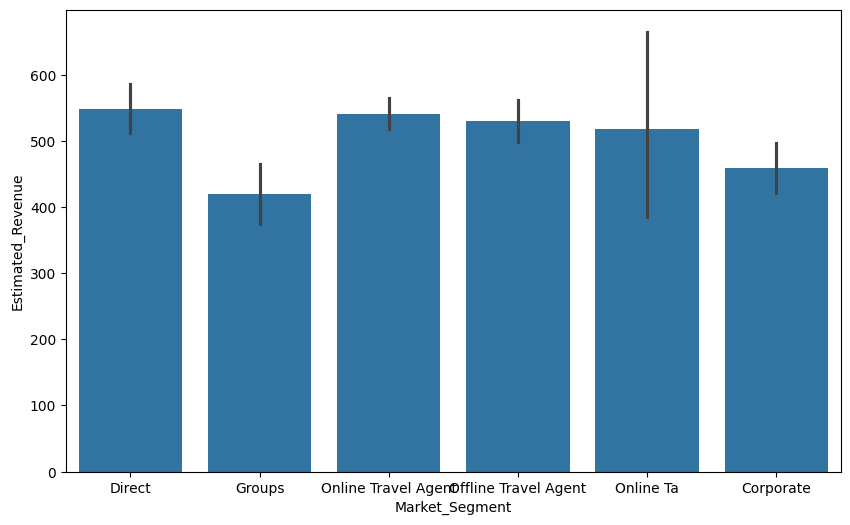

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Market_Segment',y='Estimated_Revenue')
plt.show()

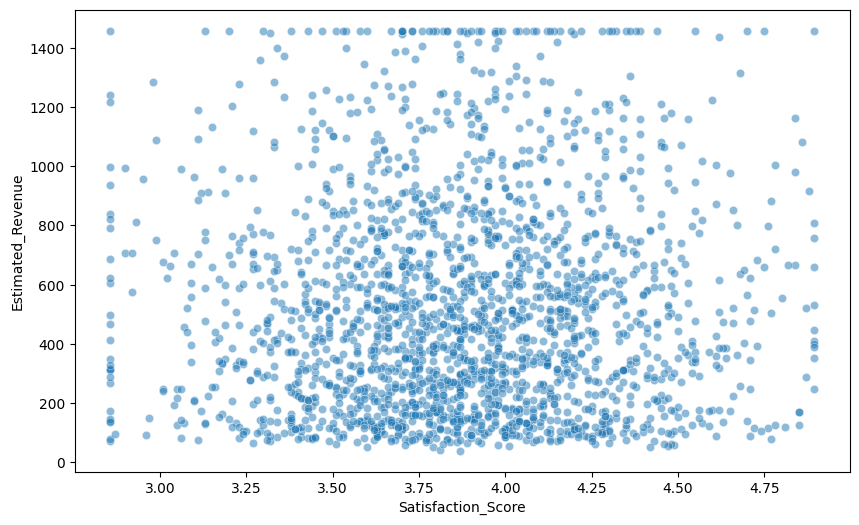

In [51]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Satisfaction_Score',y='Estimated_Revenue',alpha=0.5)
plt.show()

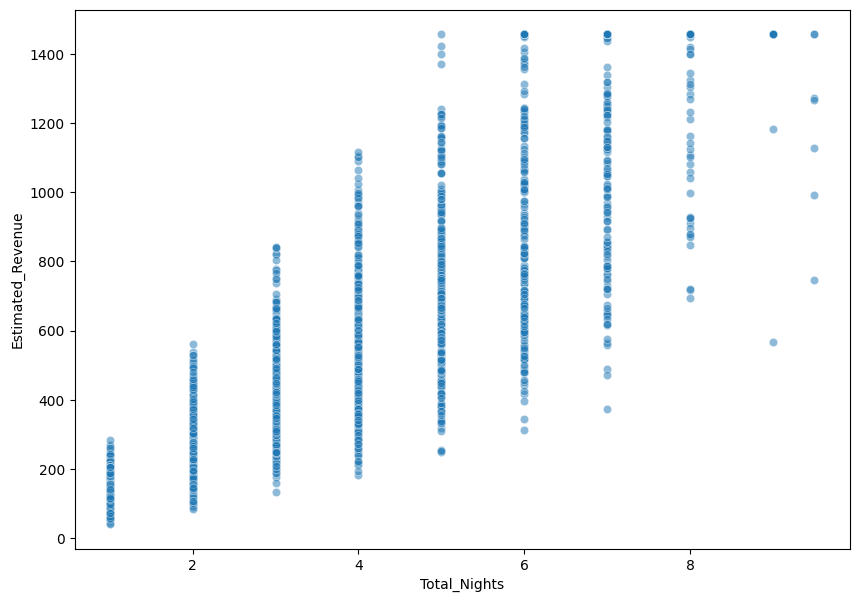

In [50]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x='Total_Nights',y='Estimated_Revenue',alpha=0.5)
plt.show()

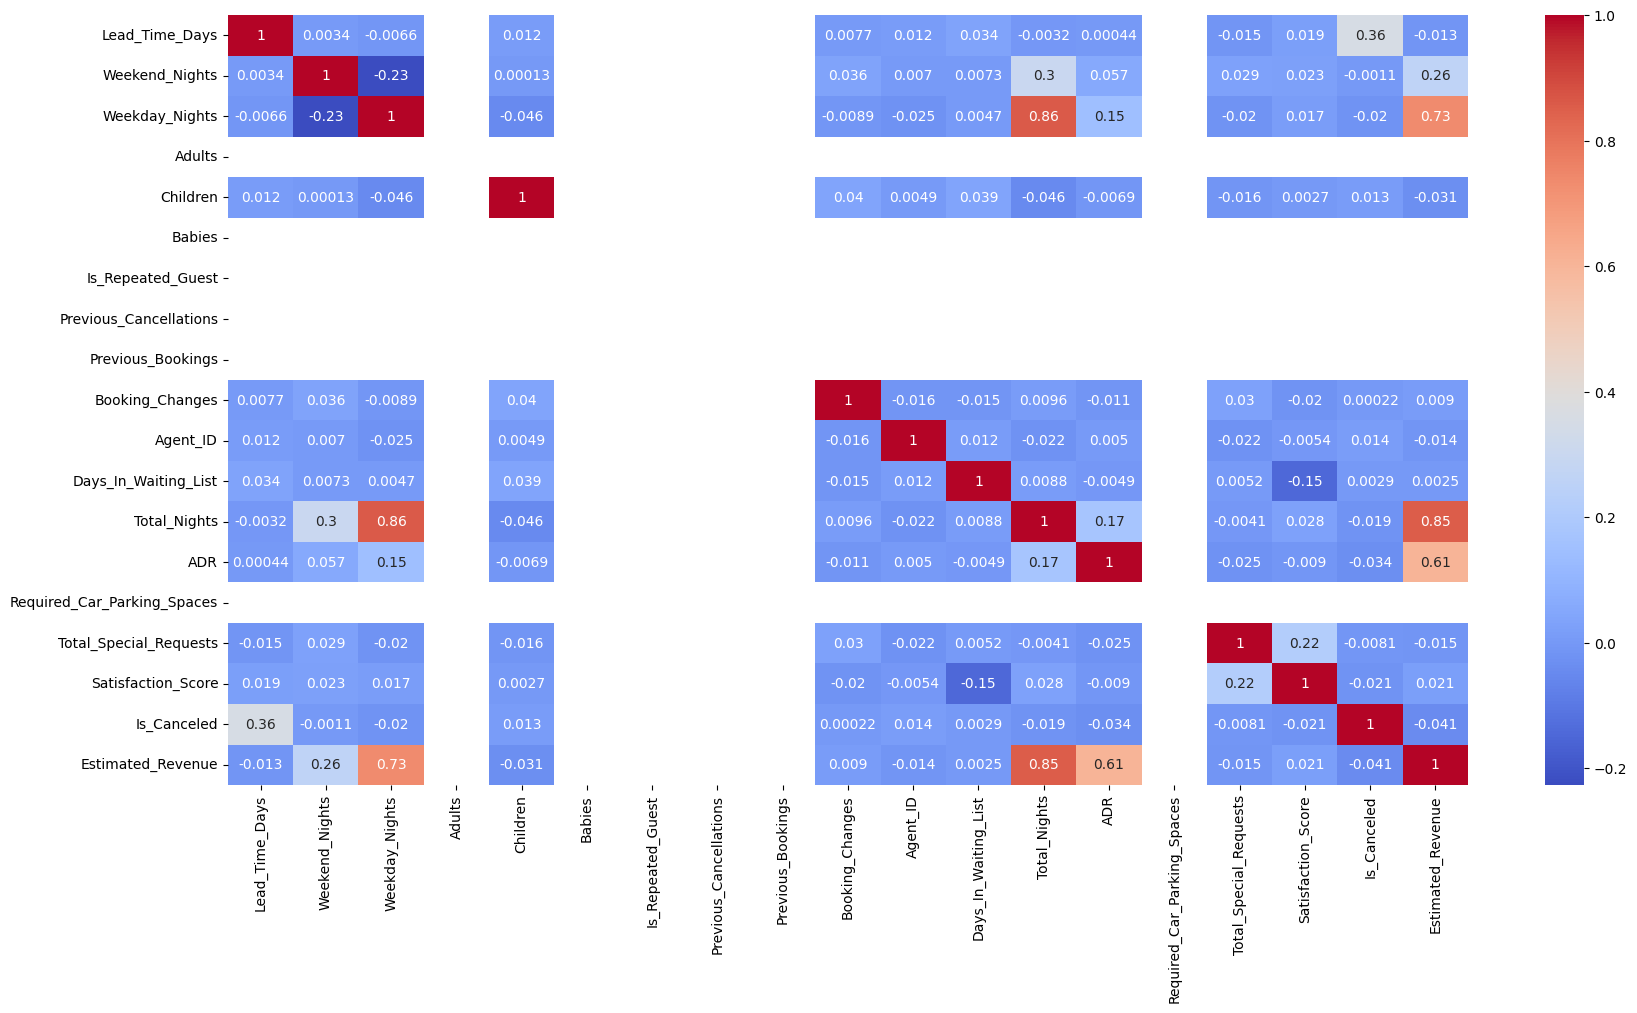

In [43]:
plt.figure(figsize=(20,10))

sns.heatmap(df.select_dtypes(include='number').corr(), annot=True,cmap="coolwarm")

plt.show()

In [55]:





# ============================================================
# 30. FINAL BUSINESS METRICS
# ============================================================

print("\n\n================================================")
print("              EXECUTIVE SUMMARY")
print("================================================")

print(
    f"\nTotal bookings analysed: {len(df):,}"
)

print(
    f"Cancellation / No-show rate: "
    f"{df['Is_Canceled'].mean()*100:.2f}%"
)

print(
    f"Average ADR: "
    f"{df['ADR'].mean():.2f}"
)

print(
    f"Median ADR: "
    f"{df['ADR'].median():.2f}"
)

print(
    f"Average total nights: "
    f"{df['Total_Nights'].mean():.2f}"
)

print(
    f"Average satisfaction score: "
    f"{df['Satisfaction_Score'].mean():.2f}"
)


# ============================================================
# 31. KEY BUSINESS INSIGHTS
# ============================================================

print("\n\n================================================")
print("              KEY BUSINESS INSIGHTS")
print("================================================")

print("""
1. Cancellation and no-show behaviour is a major
   commercial risk in the hotel booking portfolio.

2. Longer lead times are associated with higher
   cancellation risk, meaning bookings made far in
   advance require stronger monitoring and retention
   strategies.

3. Deposit type is an important cancellation-risk
   indicator. Different payment/deposit policies should
   therefore be evaluated separately.""")


# ============================================================
# 32. MANAGEMENT RECOMMENDATIONS
# ============================================================

print("\n\n================================================")
print("          MANAGEMENT RECOMMENDATIONS")
print("================================================")

print("""
1. Introduce stricter cancellation controls for
   long-lead bookings, particularly reservations made
   several months before arrival.

2. Review deposit and payment policies for segments
   with unusually high cancellation rates.

3. Develop separate strategies for city hotels and
   resort hotels based on their ADR and cancellation
   behaviour.

4. Monitor high-risk locations regularly and use
   targeted promotions, reminders, and retention
   campaigns.

5. Use cancellation patterns when planning controlled
   overbooking and room inventory allocation.

6. Monitor market segments and distribution channels
   using cancellation rate, ADR, and booking value
   together rather than bookings alone.

7. Separate estimated booking value from realized
   revenue in management dashboards.
""")

print("\n========== EDA COMPLETED ==========")



              EXECUTIVE SUMMARY

Total bookings analysed: 2,115
Cancellation / No-show rate: 71.19%
Average ADR: 140.84
Median ADR: 134.80
Average total nights: 3.62
Average satisfaction score: 3.87


              KEY BUSINESS INSIGHTS

1. Cancellation and no-show behaviour is a major
   commercial risk in the hotel booking portfolio.

2. Longer lead times are associated with higher
   cancellation risk, meaning bookings made far in
   advance require stronger monitoring and retention
   strategies.

3. Deposit type is an important cancellation-risk
   indicator. Different payment/deposit policies should
   therefore be evaluated separately.

4. Hotel types and locations have different ADR and
   cancellation profiles, so management should avoid
   using one pricing or cancellation strategy for all
   properties.

5. Estimated booking value should not automatically be
   treated as realized revenue because canceled and
   no-show reservations can still contribute to the
   estimated

In [59]:
df.columns


Index(['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date',
       'Arrival_Date', 'Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights',
       'Adults', 'Children', 'Babies', 'Country', 'Market_Segment',
       'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations',
       'Previous_Bookings', 'Room_Type_Reserved', 'Room_Type_Assigned',
       'Booking_Changes', 'Deposit_Type', 'Agent_ID', 'Company_ID',
       'Days_In_Waiting_List', 'Customer_Type', 'Meal_Type', 'Total_Nights',
       'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests',
       'Satisfaction_Score', 'Reservation_Status', 'Is_Canceled',
       'Reservation_Status_Date', 'Estimated_Revenue'],
      dtype='object')